# Notebook 2e — RF con CV por animal: Score lesional (regresión)
### Tuberculosis bovina

Target: **Score_lesional** (ordinal 0,1,2,4,5).
Pipeline de regresión con Random Forest, CV por animal sin información de explotación.

## 1. Setup e importaciones

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import RepeatedKFold, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from scipy.stats import spearmanr as scipy_spearmanr
import shap
import tb_utils as tb

PALETTE = tb.set_plot_style()
tb.set_seeds(tb.SEED)

import os

DATA = "../BD.csv"
df = tb.clean(tb.load_raw(DATA))

d = tb.target_subset(df, "Score_lesional")
d = tb.drop_sparse_rows(d)

# Features: SOLO biomarcadores — sin ninguna variable de explotación
X_all = d[tb.MODEL_FEATURES].copy()
y     = d["Score_lesional"].astype(float).values
g     = d[tb.GROUP_COL].values   # guardado para referencia; NO usado en CV

print(f"Dataset: n={len(y)}")
print(f"Features ({len(tb.MODEL_FEATURES)}): {tb.MODEL_FEATURES}")
print()
print("Distribución de Score_lesional:")
print(pd.Series(y).value_counts().sort_index())
print(f"\nMedia = {y.mean():.3f}  |  Std = {y.std():.3f}")
print(f"Baseline RMSE = std(y) (modelo nulo) = {y.std():.3f}")
print(f"\nNota: la variable explotación (granja) se IGNORA completamente.")
print(f"CV splits cruzan granjas libremente → estimación optimista.")

drop_sparse_rows: 3 fila(s) eliminada(s) (>4 NaN en features). n restante = 103.
Dataset: n=103
Features (8): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'EDAD', 'PIROPLASMA', 'THEILERIA', 'ANAPLASMA', 'RAZA2']

Distribución de Score_lesional:
0.0    40
1.0    22
2.0    15
4.0     8
5.0    18
Name: count, dtype: int64

Media = 1.689  |  Std = 1.885
Baseline RMSE = std(y) (modelo nulo) = 1.885

Nota: la variable explotación (granja) se IGNORA completamente.
CV splits cruzan granjas libremente → estimación optimista.


## 2. Random Forest y estrategia de validación cruzada

**CV por animal sin explotación (RepeatedKFold, 5×10):**
- Sin estratificación (target continuo/ordinal).
- La variable explotación **no existe** en ninguna parte del pipeline.
- Dado que animales de la misma granja pueden estar simultáneamente en train y test,
  y la granja es un fuerte confundidor, esta estimación es **optimista** respecto al
  verdadero rendimiento en nuevas granjas.
- Su valor es revelar la señal máxima extraíble de los biomarcadores bajo el supuesto
  (no verificado) de independencia entre animales de distintas granjas.

In [2]:
def make_rf_reg(n_estimators=100, min_samples_leaf=5):
    return RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=None,
        min_samples_leaf=min_samples_leaf,
        max_features="sqrt",
        random_state=tb.SEED,
        n_jobs=-1,
        oob_score=True,
    )

def make_pipe_e(feature_list, n_estimators=100):
    """Pipeline sin escalado, sin explotación."""
    num_f = [f for f in feature_list if f in tb.NUM_FEATURES]
    cat_f = [f for f in feature_list if f in tb.CAT_FEATURES]
    prep  = tb.make_preprocessor(numeric=num_f, categorical=cat_f, scale=False)
    return Pipeline([("prep", prep), ("clf", make_rf_reg(n_estimators=n_estimators))])

CV_OUTER_E = RepeatedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)

def cv_animal_metrics_e(feature_list, X, y, cv=None, detailed=False, n_estimators=100):
    """Spearman r, R² y RMSE con CV por animal (sin explotación, regresión)."""
    if cv is None:
        cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)
    Xs = X[list(feature_list)]
    pipe_tmpl = make_pipe_e(feature_list, n_estimators)
    rows = []
    for tr, te in cv.split(Xs, y):
        pf = clone(pipe_tmpl)
        pf.fit(Xs.iloc[tr], y[tr])
        pred = pf.predict(Xs.iloc[te])
        sp   = scipy_spearmanr(y[te], pred).correlation
        r2   = r2_score(y[te], pred)
        rmse = float(np.sqrt(mean_squared_error(y[te], pred)))
        rows.append(dict(spearman=sp, r2=r2, rmse=rmse))
    df_r = pd.DataFrame(rows)
    if detailed:
        return df_r
    return df_r.spearman.mean(), df_r.spearman.std()

# Evaluación baseline
print("Evaluación baseline RF (todos los features de biomarcadores, CV por animal):")
base_m, base_s = cv_animal_metrics_e(tb.MODEL_FEATURES, X_all, y)
print(f"  Spearman r = {base_m:.3f} \u00b1 {base_s:.3f}")
print(f"  Baseline nulo (siempre predice media): Spearman = 0.000")

Evaluación baseline RF (todos los features de biomarcadores, CV por animal):
  Spearman r = 0.087 ± 0.168
  Baseline nulo (siempre predice media): Spearman = 0.000


## 3. Pipeline de selección de características

Mismo algoritmo que Notebooks 2 y 2b, usando **CV por animal sin explotación**:
1. Importancia de permutación sobre modelo completo (en muestra) → ranking.
2. Eliminación hacia atrás, calculando Spearman r CV por animal en cada paso.
3. Selección: subconjunto más pequeño con Spearman ≥ máx − 1·DE.

Paso 1: Ajustando RF completo para ranking de importancia...
OOB Score R² (en muestra): -0.025

Ranking importancia de permutación (sin explotación):
                 pretty  imp_mean  imp_std
             Vitamina D    0.1749   0.0320
log(1+Carga piroplasma)    0.1570   0.0216
                 Calcio    0.0903   0.0103
            Edad (años)    0.0749   0.0155
                   Raza    0.0391   0.0108
     Anaplasma spp. (+)    0.0229   0.0055
     Theileria spp. (+)    0.0099   0.0022
         Piroplasma (+)    0.0016   0.0011


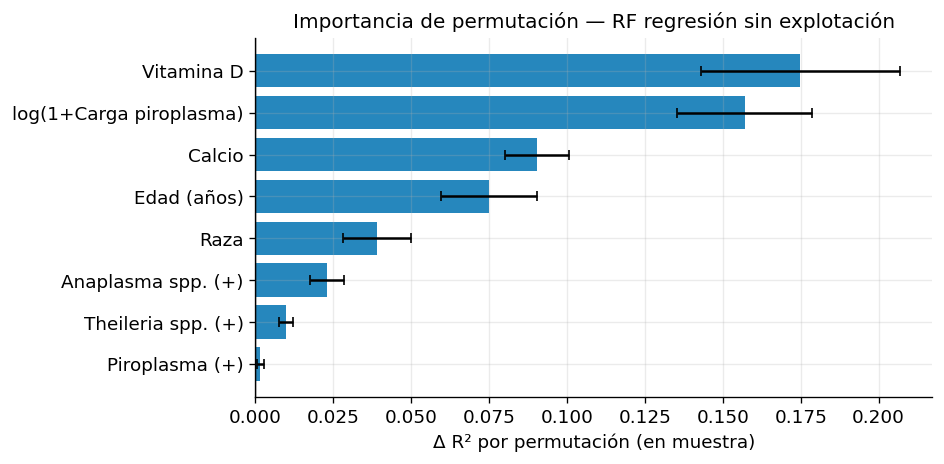

In [3]:
print("Paso 1: Ajustando RF completo para ranking de importancia...")
full_pipe = make_pipe_e(tb.MODEL_FEATURES).fit(X_all, y)
print(f"OOB Score R² (en muestra): {full_pipe.named_steps['clf'].oob_score_:.3f}")

pi = permutation_importance(
    full_pipe, X_all, y,
    scoring="r2",
    n_repeats=50,
    random_state=tb.SEED,
    n_jobs=-1,
)
imp_df = pd.DataFrame({
    "feature":  tb.MODEL_FEATURES,
    "imp_mean": pi.importances_mean,
    "imp_std":  pi.importances_std,
}).sort_values("imp_mean", ascending=False).reset_index(drop=True)
imp_df["pretty"] = imp_df.feature.map(lambda f: tb.PRETTY.get(f, f))

print("\nRanking importancia de permutación (sin explotación):")
print(imp_df[["pretty", "imp_mean", "imp_std"]].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
order = imp_df.sort_values("imp_mean")
ax.barh(order.pretty, order.imp_mean, xerr=order.imp_std, color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("\u0394 R\u00b2 por permutaci\u00f3n (en muestra)")
ax.set_title("Importancia de permutaci\u00f3n \u2014 RF regresi\u00f3n sin explotaci\u00f3n")
plt.tight_layout(); plt.savefig("figures/fig_2e_perm_importance_full.png"); plt.show()

In [4]:
CV_SEL_E = RepeatedKFold(n_splits=5, n_repeats=3, random_state=tb.SEED)
elim_order = imp_df.sort_values("imp_mean", ascending=True)["feature"].tolist()
print(f"Orden de eliminaci\u00f3n: {elim_order}\n")
print("Paso 2: Eliminaci\u00f3n hacia atr\u00e1s (CV por animal, puede tardar 1-2 min)...\n")

current_features = tb.MODEL_FEATURES.copy()
history = []

m0, s0 = cv_animal_metrics_e(current_features, X_all, y, cv=CV_SEL_E)
history.append({"n": len(current_features), "features": current_features.copy(),
                "removed": "\u2014(baseline)", "mean": m0, "std": s0})
print(f"  {len(current_features):2d} features [baseline] Spearman={m0:.3f}\u00b1{s0:.3f}")

for feat in elim_order:
    if feat not in current_features or len(current_features) <= 1:
        break
    test_feats = [f for f in current_features if f != feat]
    m, s = cv_animal_metrics_e(test_feats, X_all, y, cv=CV_SEL_E)
    history.append({"n": len(test_feats), "features": test_feats.copy(),
                    "removed": feat, "mean": m, "std": s})
    print(f"  {len(test_feats):2d} features [-{feat:20s}] Spearman={m:.3f}\u00b1{s:.3f}  \u0394={m-m0:+.3f}")
    current_features = test_feats

hist_df = pd.DataFrame(history)

Orden de eliminación: ['PIROPLASMA', 'THEILERIA', 'ANAPLASMA', 'RAZA2', 'EDAD', 'CALCIO', 'PIROPLASMA_Q_log', 'VITAMINA_D']

Paso 2: Eliminación hacia atrás (CV por animal, puede tardar 1-2 min)...

   8 features [baseline] Spearman=0.093±0.125
   7 features [-PIROPLASMA          ] Spearman=0.081±0.156  Δ=-0.012
   6 features [-THEILERIA           ] Spearman=0.073±0.167  Δ=-0.020
   5 features [-ANAPLASMA           ] Spearman=0.114±0.130  Δ=+0.021
   4 features [-RAZA2               ] Spearman=0.107±0.162  Δ=+0.013
   3 features [-EDAD                ] Spearman=0.164±0.178  Δ=+0.071
   2 features [-CALCIO              ] Spearman=0.228±0.215  Δ=+0.134
   1 features [-PIROPLASMA_Q_log    ] Spearman=0.150±0.209  Δ=+0.057


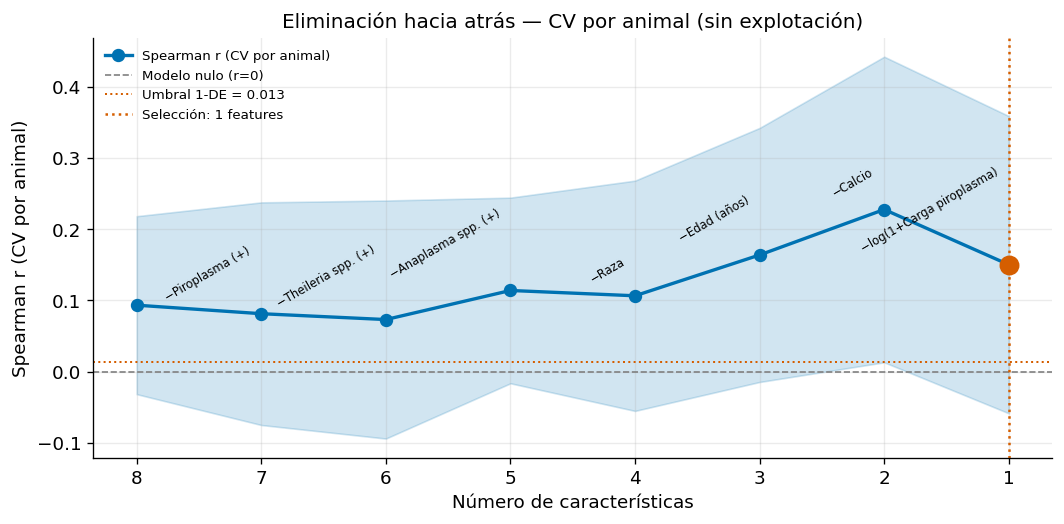


Features SELECCIONADOS (1): ['VITAMINA_D']


In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist_df.n, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7, label="Spearman r (CV por animal)")
ax.fill_between(hist_df.n,
                hist_df["mean"] - hist_df["std"],
                hist_df["mean"] + hist_df["std"], alpha=0.18, color=PALETTE[0])
ax.axhline(0, ls="--", color="grey", lw=1, label="Modelo nulo (r=0)")

best_idx     = hist_df["mean"].idxmax()
best_mu      = hist_df["mean"].max()
best_sd      = hist_df.loc[best_idx, "std"]
threshold    = best_mu - best_sd
parsimonious = hist_df[hist_df["mean"] >= threshold].sort_values("n").iloc[0]

ax.axhline(threshold, ls=":", color=PALETTE[1], lw=1.2, label=f"Umbral 1-DE = {threshold:.3f}")
ax.axvline(parsimonious.n, color=PALETTE[1], ls=":", lw=1.5,
           label=f"Selecci\u00f3n: {int(parsimonious.n)} features")
ax.scatter([parsimonious.n], [parsimonious["mean"]], color=PALETTE[1], s=120, zorder=5)

for _, row in hist_df.iterrows():
    label = tb.PRETTY.get(row.removed, row.removed) if row.removed != "\u2014(baseline)" else ""
    if label:
        ax.annotate(f"\u2212{label}", (row.n, row["mean"]),
                    textcoords="offset points", xytext=(-5, 8),
                    fontsize=7, ha="right", rotation=30)

ax.set_xlabel("N\u00famero de caracter\u00edsticas")
ax.set_ylabel("Spearman r (CV por animal)")
ax.set_title("Eliminaci\u00f3n hacia atr\u00e1s \u2014 CV por animal (sin explotaci\u00f3n)")
ax.legend(fontsize=8); ax.invert_xaxis()
plt.tight_layout(); plt.savefig("figures/fig_2e_feature_selection_curve.png"); plt.show()

SELECTED_E = list(parsimonious.features)
print(f"\nFeatures SELECCIONADOS ({len(SELECTED_E)}): {SELECTED_E}")

In [6]:
def _cv_r2(feature_list, X, y, cv):
    Xs = X[list(feature_list)]
    pipe_tmpl = make_pipe_e(feature_list)
    r2s = []
    for tr, te in cv.split(Xs, y):
        pf = clone(pipe_tmpl)
        pf.fit(Xs.iloc[tr], y[tr])
        r2s.append(r2_score(y[te], pf.predict(Xs.iloc[te])))
    return np.mean(r2s), np.std(r2s)

print("Calculando R\u00b2 para cada subconjunto de hist_df (\u224801 min)...")
r2_means, r2_stds = [], []
for _, row in hist_df.iterrows():
    m, s = _cv_r2(row["features"], X_all, y, CV_SEL_E)
    r2_means.append(m)
    r2_stds.append(s)
    print(f"  {int(row.n):2d} features [-{row['removed']:20s}] R\u00b2={m:.3f}\u00b1{s:.3f}")

hist_df = hist_df.assign(r2_mean=r2_means, r2_std=r2_stds)
print("\nhist_df actualizado con columnas r2_mean / r2_std.")

Calculando R² para cada subconjunto de hist_df (≈01 min)...
   8 features [-—(baseline)         ] R²=-0.166±0.283
   7 features [-PIROPLASMA          ] R²=-0.169±0.307
   6 features [-THEILERIA           ] R²=-0.160±0.280
   5 features [-ANAPLASMA           ] R²=-0.149±0.258
   4 features [-RAZA2               ] R²=-0.176±0.304
   3 features [-EDAD                ] R²=-0.124±0.311
   2 features [-CALCIO              ] R²=-0.089±0.344
   1 features [-PIROPLASMA_Q_log    ] R²=-0.201±0.333

hist_df actualizado con columnas r2_mean / r2_std.


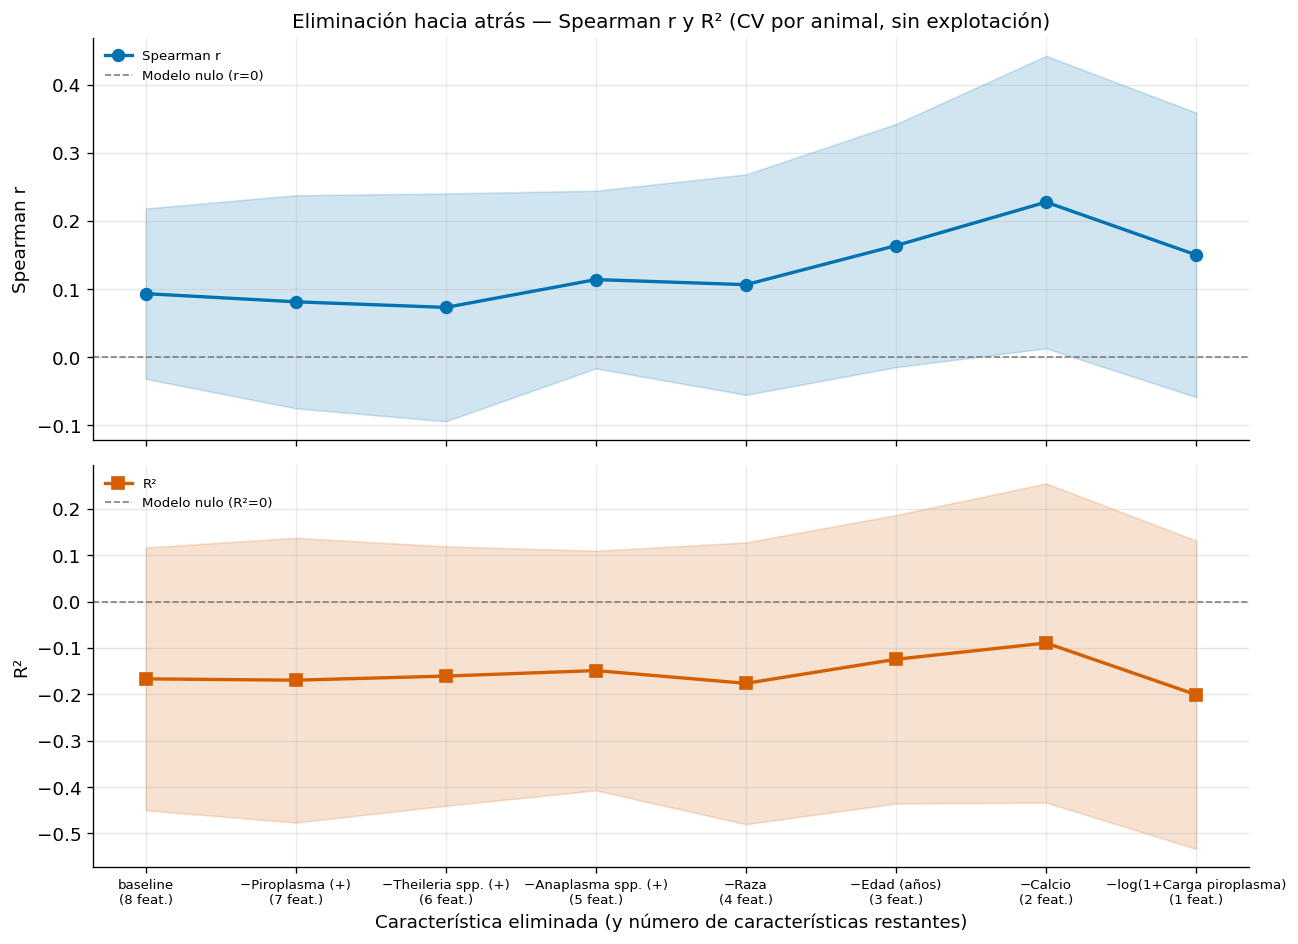

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

x      = np.arange(len(hist_df))
labels = []
for _, row in hist_df.iterrows():
    if row["removed"] == "\u2014(baseline)":
        lbl = f"baseline\n({int(row.n)} feat.)"
    else:
        pretty = tb.PRETTY.get(row["removed"], row["removed"])
        lbl = f"\u2212{pretty}\n({int(row.n)} feat.)"
    labels.append(lbl)

# --- Spearman r ---
ax1 = axes[0]
ax1.plot(x, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7, label="Spearman r")
ax1.fill_between(x,
                 hist_df["mean"] - hist_df["std"],
                 hist_df["mean"] + hist_df["std"],
                 alpha=0.18, color=PALETTE[0])
ax1.axhline(0, ls="--", color="grey", lw=1, label="Modelo nulo (r=0)")
ax1.set_ylabel("Spearman r")
ax1.legend(fontsize=8)
ax1.set_title("Eliminaci\u00f3n hacia atr\u00e1s \u2014 Spearman r y R\u00b2 (CV por animal, sin explotaci\u00f3n)")
ax1.grid(axis="y", alpha=0.3)

# --- R² ---
ax2 = axes[1]
ax2.plot(x, hist_df["r2_mean"], "s-", color=PALETTE[1], lw=2, ms=7, label="R\u00b2")
ax2.fill_between(x,
                 hist_df["r2_mean"] - hist_df["r2_std"],
                 hist_df["r2_mean"] + hist_df["r2_std"],
                 alpha=0.18, color=PALETTE[1])
ax2.axhline(0, ls="--", color="grey", lw=1, label="Modelo nulo (R\u00b2=0)")
ax2.set_ylabel("R\u00b2")
ax2.legend(fontsize=8)
ax2.grid(axis="y", alpha=0.3)

ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=8, ha="center")
ax2.set_xlabel("Caracter\u00edstica eliminada (y n\u00famero de caracter\u00edsticas restantes)")

plt.tight_layout()
plt.savefig("figures/fig_2e_feature_selection_metrics.png", bbox_inches="tight")
plt.show()

## 4. Evaluación del modelo final (CV por animal, 5×10)

Features (3): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']

Métricas CV por animal (5×10, sin explotación):
  Spearman = 0.178 ± 0.172
  R²       = -0.041 ± 0.215
  RMSE     = 1.852 ± 0.197
  Baseline RMSE (modelo nulo) = 1.885


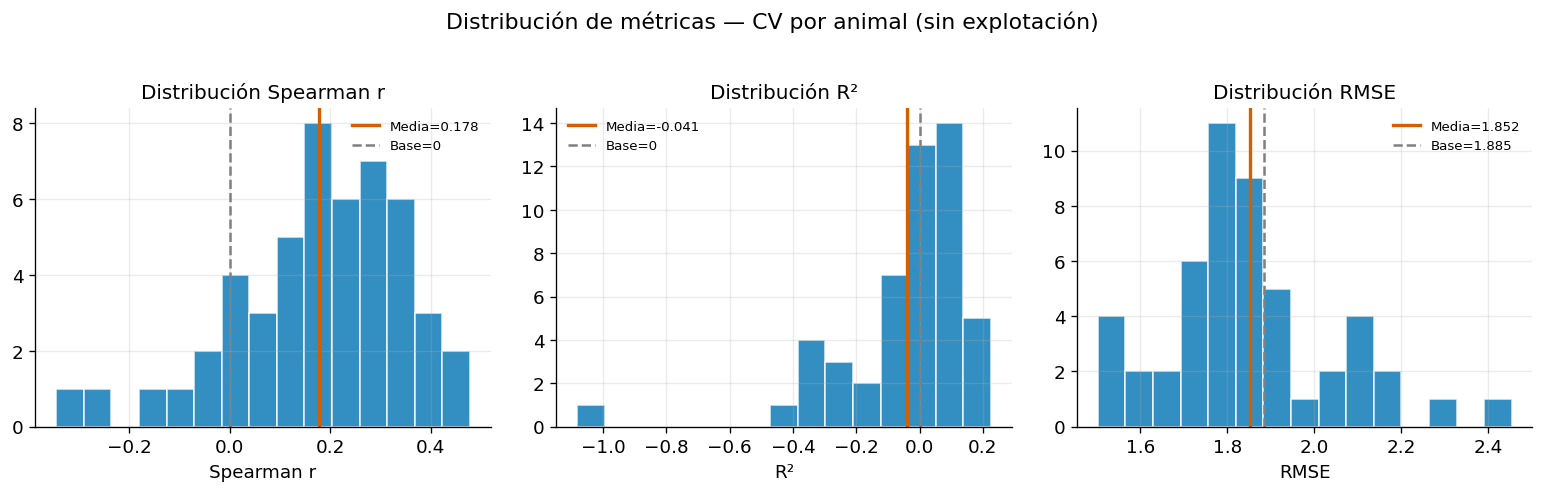

In [8]:
# Opcionalmente forzar selección manual aquí
# SELECTED_E = ["VITAMINA_D", "CALCIO", "EDAD"]
SELECTED_E = ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']

Xs = X_all[SELECTED_E].copy()
print(f"Features ({len(SELECTED_E)}): {SELECTED_E}\n")

detailed_df = cv_animal_metrics_e(SELECTED_E, X_all, y, cv=CV_OUTER_E, detailed=True, n_estimators=700)
m = detailed_df.mean(); s = detailed_df.std()

print("M\u00e9tricas CV por animal (5\u00d710, sin explotaci\u00f3n):")
print(f"  Spearman = {m.spearman:.3f} \u00b1 {s.spearman:.3f}")
print(f"  R\u00b2       = {m.r2:.3f} \u00b1 {s.r2:.3f}")
print(f"  RMSE     = {m.rmse:.3f} \u00b1 {s.rmse:.3f}")
print(f"  Baseline RMSE (modelo nulo) = {y.std():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes,
                          ["spearman", "r2", "rmse"],
                          ["Spearman r", "R\u00b2", "RMSE"]):
    ax.hist(detailed_df[col].dropna(), bins=15, color=PALETTE[0], alpha=0.8, edgecolor="white")
    ax.axvline(detailed_df[col].mean(), color=PALETTE[1], lw=2,
               label=f"Media={detailed_df[col].mean():.3f}")
    if col in ("spearman", "r2"):
        ax.axvline(0, color="grey", ls="--", lw=1.5, label="Base=0")
    if col == "rmse":
        ax.axvline(y.std(), color="grey", ls="--", lw=1.5, label=f"Base={y.std():.3f}")
    ax.set_xlabel(title); ax.set_title(f"Distribuci\u00f3n {title}"); ax.legend(fontsize=8)
plt.suptitle("Distribuci\u00f3n de m\u00e9tricas \u2014 CV por animal (sin explotaci\u00f3n)", y=1.02)
plt.tight_layout(); plt.savefig("figures/fig_2e_metrics_dist.png", bbox_inches="tight"); plt.show()

## 5. Interpretabilidad global — SHAP

Este análisis muestra la importancia de los biomarcadores **en ausencia de información
de granja**. Cualquier señal detectada aquí es potencialmente transferible a nuevas granjas
(si el modelo generalizara bien, lo cual debe verificarse con LOFO — Notebook 2).

In [10]:
FINAL_E = make_pipe_e(SELECTED_E, n_estimators=500).fit(Xs, y)
print(f"OOB Score R² (en muestra): {FINAL_E.named_steps['clf'].oob_score_:.3f}")

prep_e  = FINAL_E.named_steps["prep"]
clf_e   = FINAL_E.named_steps["clf"]
Xt_e    = prep_e.transform(Xs)
names_e = list(prep_e.get_feature_names_out())

explainer_e = shap.TreeExplainer(clf_e)
sv_e = np.asarray(explainer_e.shap_values(Xt_e))
if sv_e.ndim == 3:          # SHAP nuevo puede añadir dimensión extra en regresión
    sv_e = sv_e[:, :, 0]

# expected_value puede ser array 1D en versiones recientes de SHAP
exp_val_e = float(np.asarray(explainer_e.expected_value).ravel()[0])

print(f"Features: {names_e}")
print(f"SHAP shape: {sv_e.shape}  |  expected_value: {exp_val_e:.4f}")


OOB Score R² (en muestra): 0.035
Features: ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']
SHAP shape: (103, 3)  |  expected_value: 1.6920


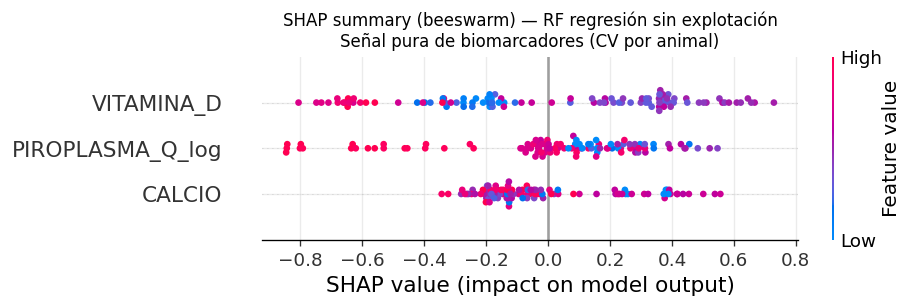

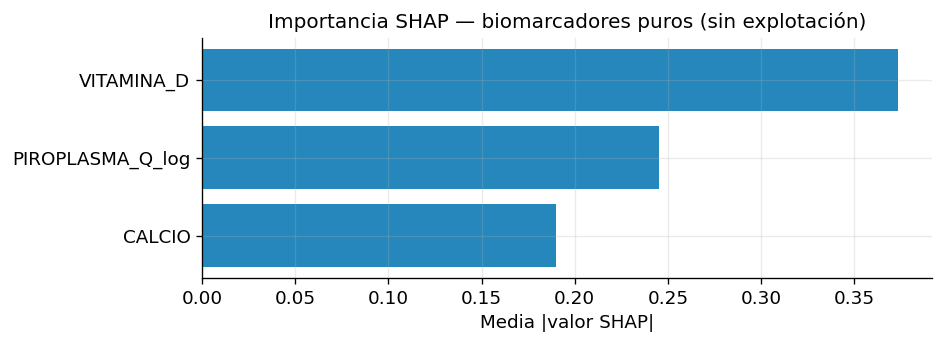

In [11]:
plt.figure(figsize=(9, max(4, 0.5 * len(names_e))))
shap.summary_plot(sv_e, Xt_e, feature_names=names_e, show=False, max_display=len(names_e))
plt.title("SHAP summary (beeswarm) \u2014 RF regresi\u00f3n sin explotaci\u00f3n\n"
          "Se\u00f1al pura de biomarcadores (CV por animal)", fontsize=10)
plt.tight_layout(); plt.savefig("figures/fig_2e_shap_summary.png", bbox_inches="tight"); plt.show()

# Importancia media |SHAP|
mean_abs_e = np.abs(sv_e).mean(0)
si_e = pd.DataFrame({"feature": names_e, "mean_abs": mean_abs_e}).sort_values("mean_abs")
fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(names_e))))
ax.barh(si_e.feature, si_e.mean_abs, color=PALETTE[0], alpha=0.85)
ax.set_xlabel("Media |valor SHAP|")
ax.set_title("Importancia SHAP \u2014 biomarcadores puros (sin explotaci\u00f3n)")
plt.tight_layout(); plt.savefig("figures/fig_2e_shap_importance.png"); plt.show()

In [12]:
shap.initjs()

order = np.argsort(FINAL_E.predict(Xs))
fp = shap.force_plot(
    exp_val_e,
    sv_e[order],
    Xt_e[order],
    feature_names=names_e,
)
shap.save_html("figures/fig_2e_shap_force_plot_global.html", fp)
display(fp)

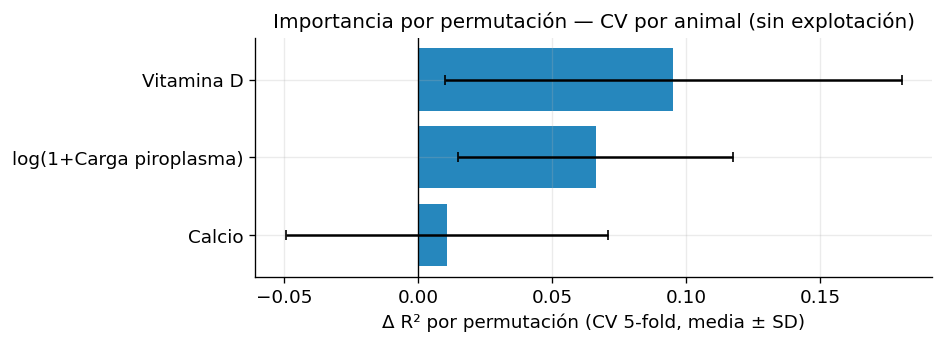

Estabilidad Spearman entre folds: -0.100


In [13]:
# Importancia por permutación — estabilidad
imp_runs_e = []
cv_stab = KFold(n_splits=5, shuffle=True, random_state=tb.SEED)
for tr, te in cv_stab.split(Xs, y):
    pf = clone(make_pipe_e(SELECTED_E)).fit(Xs.iloc[tr], y[tr])
    pi_f = permutation_importance(pf, Xs.iloc[te], y[te],
                                  scoring="r2", n_repeats=20,
                                  random_state=tb.SEED)
    imp_runs_e.append(pd.Series(pi_f.importances_mean, index=SELECTED_E))

imp_mat_e = pd.concat(imp_runs_e, axis=1)
imp_ord_e = imp_mat_e.mean(axis=1).sort_values().index

from scipy.stats import spearmanr
R = imp_mat_e.fillna(0)
cors = [spearmanr(R.iloc[:, i], R.iloc[:, j]).correlation
        for i in range(R.shape[1]) for j in range(i + 1, R.shape[1])]

fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(SELECTED_E))))
ax.barh([tb.PRETTY.get(f, f) for f in imp_ord_e],
        imp_mat_e.mean(axis=1)[imp_ord_e],
        xerr=imp_mat_e.std(axis=1)[imp_ord_e],
        color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("\u0394 R\u00b2 por permutaci\u00f3n (CV 5-fold, media \u00b1 SD)")
ax.set_title("Importancia por permutaci\u00f3n \u2014 CV por animal (sin explotaci\u00f3n)")
plt.tight_layout(); plt.savefig("figures/fig_2e_perm_importance_cv.png"); plt.show()
print(f"Estabilidad Spearman entre folds: {np.nanmean(cors):.3f}")

## 6. Partial Dependence Plots + ICE

Features continuas para PDP/ICE: ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']


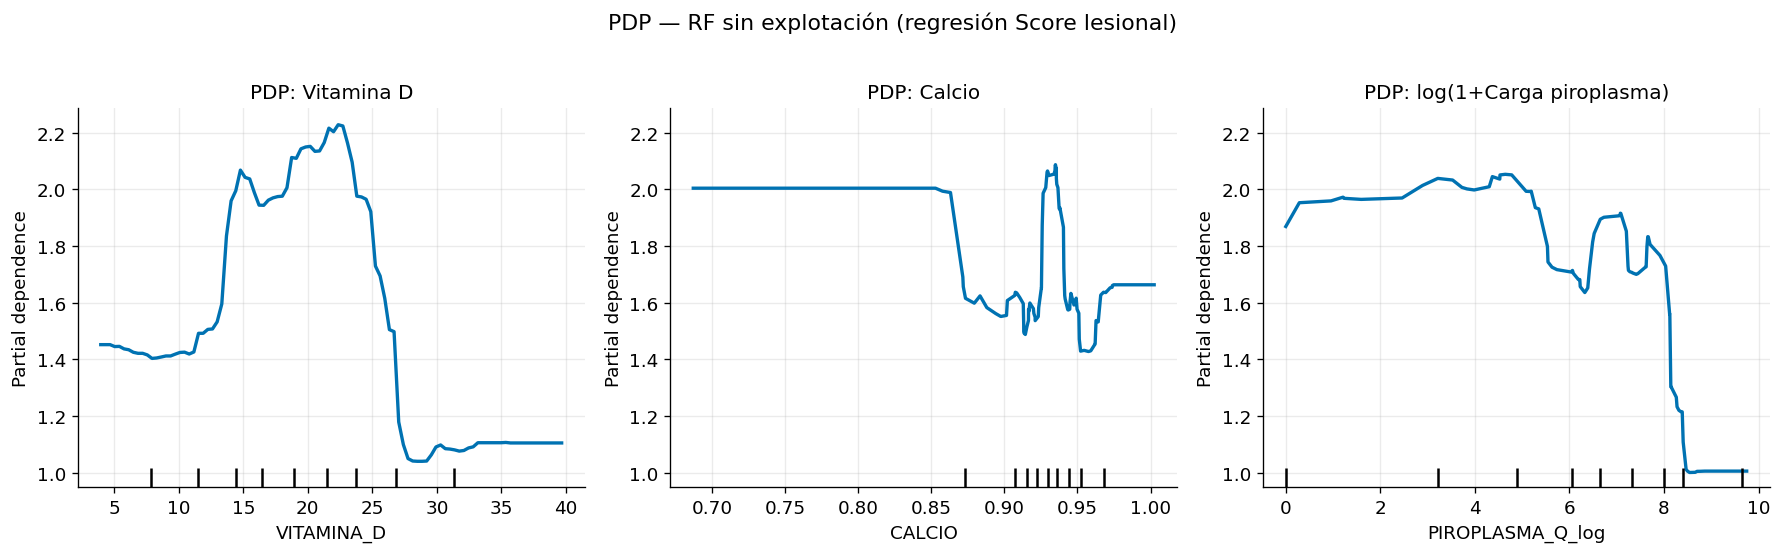

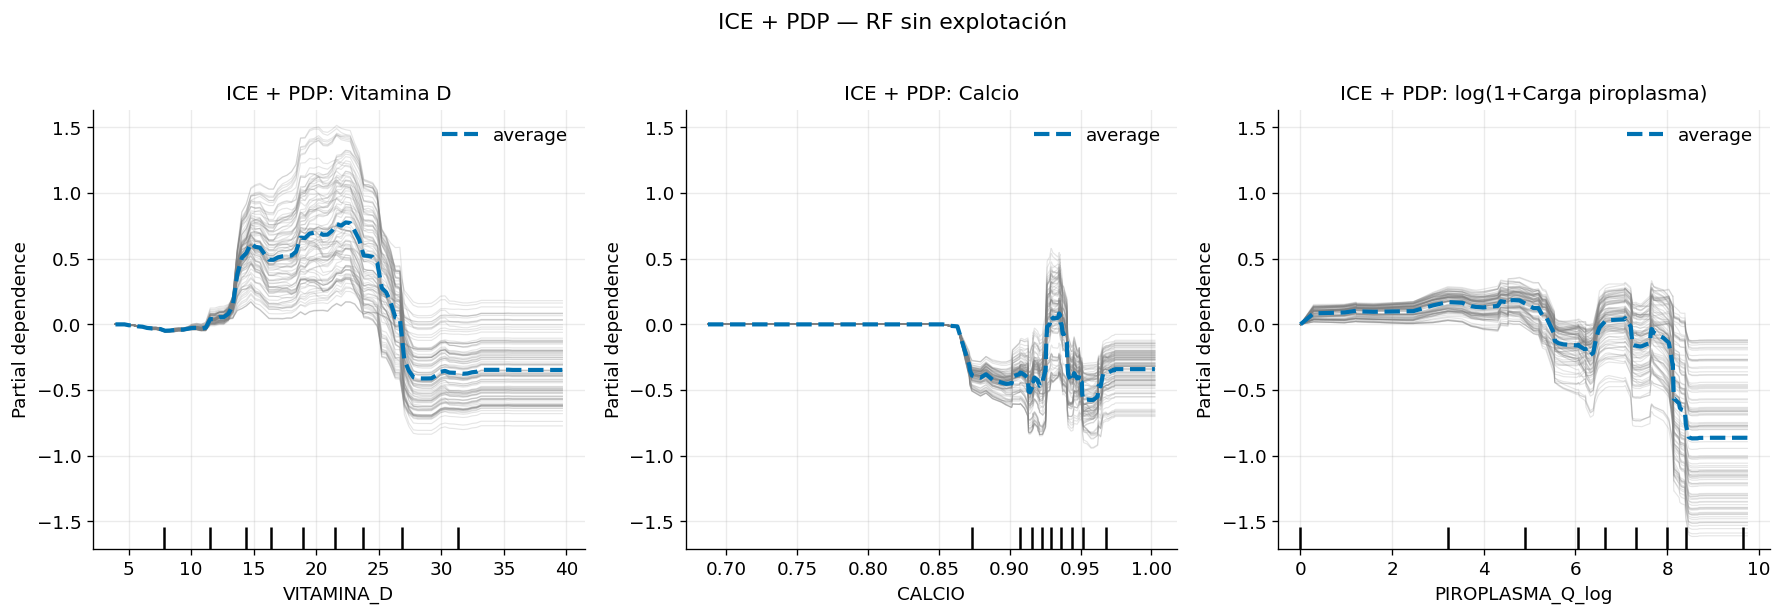

In [14]:
CONT_E = [f for f in SELECTED_E if f in tb.NUM_FEATURES and Xs[f].nunique() > 5]
if not CONT_E:
    CONT_E = [f for f in SELECTED_E if f in tb.NUM_FEATURES]

print(f"Features continuas para PDP/ICE: {CONT_E}")
if CONT_E:
    n_c = len(CONT_E)
    # PDP
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4.5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_E, Xs, CONT_E, kind="average",
        ax=axes, line_kw={"color": PALETTE[0], "lw": 2})
    for ax, f in zip(axes, CONT_E):
        ax.set_title(f"PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle("PDP \u2014 RF sin explotaci\u00f3n (regresi\u00f3n Score lesional)", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_2e_pdp.png", bbox_inches="tight"); plt.show()

    # ICE + PDP
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_E, Xs, CONT_E, kind="both",
        ax=axes,
        ice_lines_kw={"color": "grey", "alpha": 0.2, "lw": 0.7},
        pd_line_kw={"color": PALETTE[0], "lw": 2.5},
        centered=True)
    for ax, f in zip(axes, CONT_E):
        ax.set_title(f"ICE + PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle("ICE + PDP \u2014 RF sin explotaci\u00f3n", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_2e_ice.png", bbox_inches="tight"); plt.show()

## 7. Accumulated Local Effects (ALE)

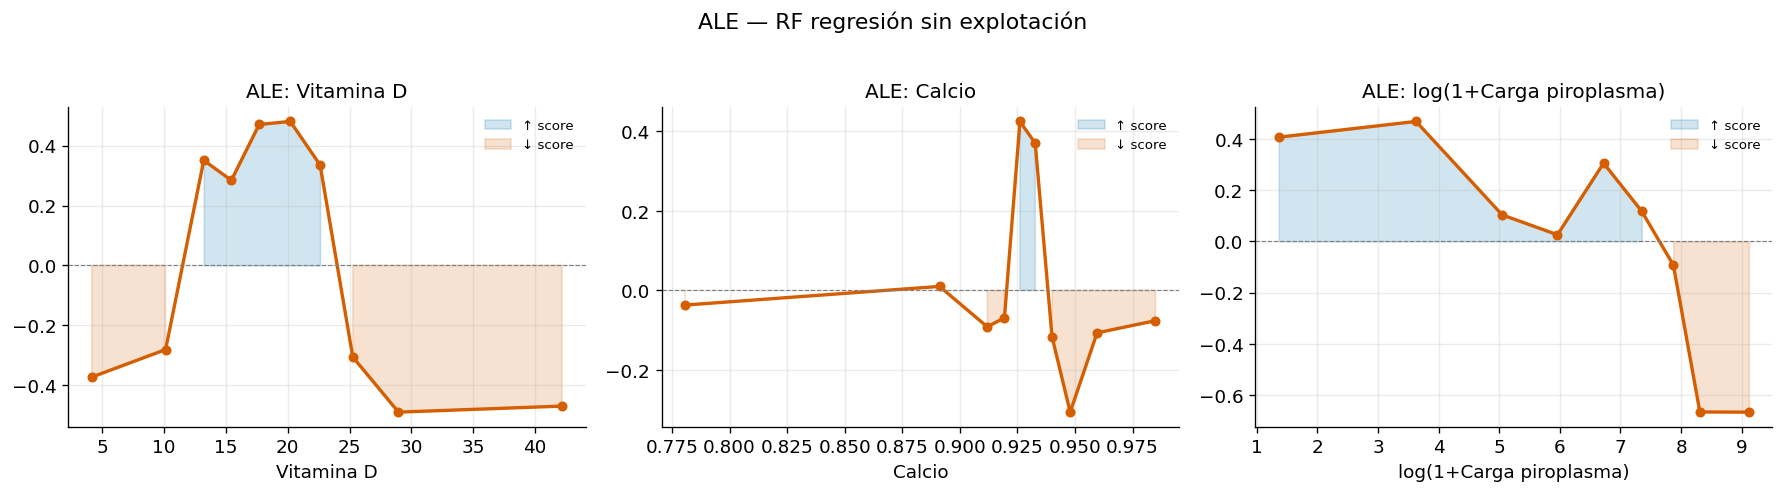

In [15]:
def ale_1d_reg(model, X, feat, bins=10):
    x = X[feat].dropna().values
    q = np.quantile(x, np.linspace(0, 1, bins + 1)); q = np.unique(q)
    if len(q) < 3: return np.array([]), np.array([])
    eff, Xc = [], X.copy()
    for i in range(len(q) - 1):
        mask = (X[feat] >= q[i]) & (X[feat] <= q[i + 1])
        if mask.sum() == 0: eff.append(0.0); continue
        lo = Xc.loc[mask].copy(); lo[feat] = q[i]
        hi = Xc.loc[mask].copy(); hi[feat] = q[i + 1]
        eff.append((model.predict(hi) - model.predict(lo)).mean())
    ale = np.cumsum(eff); ale -= ale.mean()
    return (q[:-1] + q[1:]) / 2, ale

if CONT_E:
    n_c = len(CONT_E)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_E):
        cx, ale = ale_1d_reg(FINAL_E, Xs, feat)
        if len(cx) == 0: ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}\n(insuf.)"); continue
        ax.plot(cx, ale, "o-", color=PALETTE[1], lw=2, ms=5)
        ax.axhline(0, color="grey", lw=0.7, ls="--")
        ax.fill_between(cx, 0, ale, where=(ale > 0), alpha=0.18, color=PALETTE[0], label="\u2191 score")
        ax.fill_between(cx, 0, ale, where=(ale < 0), alpha=0.18, color=PALETTE[1], label="\u2193 score")
        ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}")
        ax.set_xlabel(tb.PRETTY.get(feat,feat)); ax.legend(fontsize=8)
    plt.suptitle("ALE \u2014 RF regresi\u00f3n sin explotaci\u00f3n", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_2e_ale.png", bbox_inches="tight"); plt.show()

## 8. SHAP waterfall — interpretabilidad local

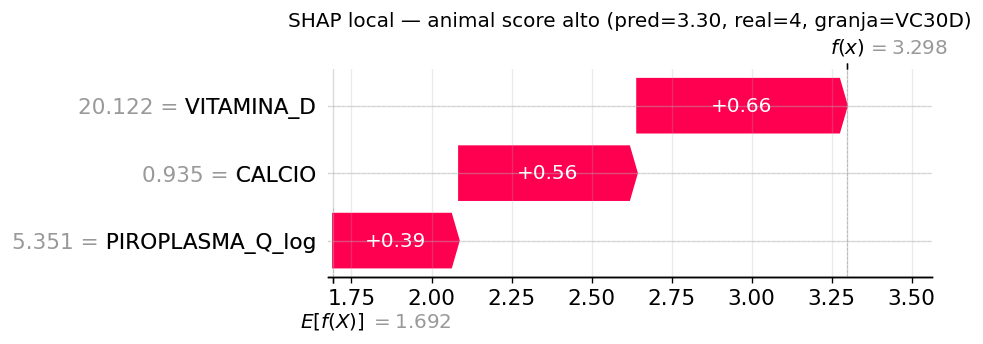

Animal 51: pred=3.30, Score real=4, granja (ref)=VC30D


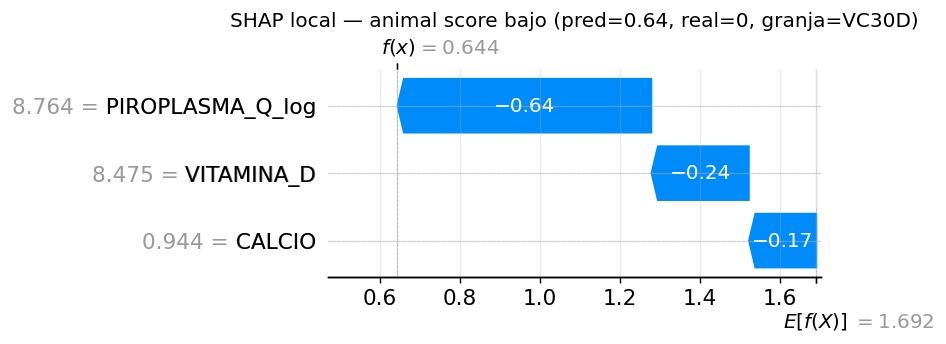

Animal 46: pred=0.64, Score real=0, granja (ref)=VC30D


In [16]:
p_all_e  = FINAL_E.predict(Xs)
idx_pos  = int(np.argmax(p_all_e))   # animal con mayor Score_lesional predicho
idx_neg  = int(np.argmin(p_all_e))   # animal con menor Score_lesional predicho

shap_exp_e = shap.Explanation(values=sv_e, base_values=exp_val_e,
                               data=Xt_e, feature_names=names_e)

for tag, idx in [("score_alto", idx_pos), ("score_bajo", idx_neg)]:
    farm_ref = g[idx]
    fig, _ = plt.subplots(figsize=(9, 4))
    shap.plots.waterfall(shap_exp_e[idx], max_display=len(names_e), show=False)
    plt.title(f"SHAP local \u2014 animal {tag.replace('_',' ')} "
              f"(pred={p_all_e[idx]:.2f}, real={y[idx]:.0f}, granja={farm_ref})")
    plt.tight_layout()
    plt.savefig(f"figures/fig_2e_waterfall_{tag}.png", bbox_inches="tight"); plt.show()
    print(f"Animal {idx}: pred={p_all_e[idx]:.2f}, Score real={y[idx]:.0f}, granja (ref)={farm_ref}")

## 9. Contrafactuales

In [17]:
def find_cf_reg(model, row_dict, feat, lo, hi, threshold, direction="above", n=500):
    """Encuentra el valor de feat que lleva la predicci\u00f3n por encima/debajo del umbral."""
    for v in np.linspace(lo, hi, n):
        r = dict(row_dict); r[feat] = v
        pred = model.predict(pd.DataFrame([r]))[0]
        if direction == "above" and pred >= threshold:
            return v, pred
        if direction == "below" and pred <= threshold:
            return v, pred
    return None, None

threshold_cf = float(np.median(y))
high_row = Xs.iloc[idx_pos].copy()
low_row  = Xs.iloc[idx_neg].copy()

print("=" * 60)
print("CONTRAFACTUALES \u2014 solo con biomarcadores")
print(f"Umbral = mediana(y) = {threshold_cf:.1f}")
print("=" * 60)

for tag, row, direction in [("SCORE ALTO", high_row, "below"),
                             ("SCORE BAJO", low_row, "above")]:
    pred = FINAL_E.predict(pd.DataFrame([row]))[0]
    print(f"\nAnimal {tag} (predicci\u00f3n={pred:.2f}), objetivo \u2192 "
          f"{'por debajo' if direction=='below' else 'por encima'} de {threshold_cf:.1f}")
    for feat in CONT_E:
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        cf_val, cf_pred = find_cf_reg(FINAL_E, row.to_dict(), feat,
                                      lo_v, hi_v, threshold_cf, direction)
        cur = row[feat]
        if cf_val is not None:
            print(f"  {tb.PRETTY.get(feat,feat):30s}: actual={cur:.2f} \u2192 cf={cf_val:.2f} "
                  f"(\u0394={cf_val-cur:+.2f}, pred_cf={cf_pred:.2f})")
        else:
            print(f"  {tb.PRETTY.get(feat,feat):30s}: actual={cur:.2f} \u2192 no alcanzable")

CONTRAFACTUALES — solo con biomarcadores
Umbral = mediana(y) = 1.0

Animal SCORE ALTO (predicción=3.30), objetivo → por debajo de 1.0
  Vitamina D                    : actual=20.12 → no alcanzable
  Calcio                        : actual=0.93 → no alcanzable
  log(1+Carga piroplasma)       : actual=5.35 → no alcanzable

Animal SCORE BAJO (predicción=0.64), objetivo → por encima de 1.0
  Vitamina D                    : actual=8.48 → cf=19.16 (Δ=+10.68, pred_cf=1.00)
  Calcio                        : actual=0.94 → cf=0.69 (Δ=-0.26, pred_cf=1.25)
  log(1+Carga piroplasma)       : actual=8.76 → cf=0.00 (Δ=-8.76, pred_cf=1.40)


In [ ]:
if CONT_E:
    n_c = len(CONT_E)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_E):
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        grid = np.linspace(lo_v, hi_v, 200)
        for tag, row, color in [("Score alto", high_row, PALETTE[1]),
                                 ("Score bajo", low_row, PALETTE[0])]:
            preds = [FINAL_E.predict(pd.DataFrame([{**row.to_dict(), feat: v}]))[0] for v in grid]
            ax.plot(grid, preds, color=color, lw=2, label=tag)
            ax.axvline(row[feat], color=color, ls=":", lw=1.2, alpha=0.7)
        ax.axhline(threshold_cf, color="grey", ls="--", lw=0.8,
                   label=f"Umbral mediana ({threshold_cf:.1f})")
        ax.set_xlabel(tb.PRETTY.get(feat, feat))
        ax.set_ylabel("Score lesional predicho")
        ax.set_title(f"Contrafactual: {tb.PRETTY.get(feat,feat)}"); ax.legend(fontsize=8)
    plt.suptitle("Sensibilidad contrafactual \u2014 RF regresi\u00f3n sin explotaci\u00f3n", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_2e_cf_curves.png", bbox_inches="tight"); plt.show()

## 10. Síntesis y triangulación

### Tabla comparativa (rellenar con resultados)

| Métrica | Nb 2e — CV sin expl (Score lesional) |
|---|---|
| Spearman r | — |
| R² | — |
| RMSE | — |
| CV strategy | RepeatedKFold (5×10) |
| Expl como feature | No |
| Expl en CV split | No |

### Guía de interpretación

- **Spearman r > 0 con IC > 0:** existe señal ordinal en los biomarcadores para predecir la
  severidad lesional.
- **R² > 0:** el modelo explica varianza más allá del modelo nulo (media constante).
- **RMSE < std(y):** el modelo supera la predicción nula en términos de error absoluto.
- **Comparar con LOFO (Nb 2):** si Spearman(2e) >> Spearman(LOFO), la señal existe
  dentro de granjas pero no generaliza entre granjas.

### Implicaciones clínicas
Los contrafactuales de biomarcadores en este notebook representan la palanca de intervención
más directamente clínica para Score lesional: son cambios en marcadores medibles sin
información de granja. Si estos contrafactuales son alcanzables en el rango observado,
sugieren posibles umbrales diagnósticos o de severidad a validar en estudios futuros.